# Análise da Produção e Faturamento de Mel no Brasil

## 1. Introdução

**Membros da Equipe**: Gabriel de Jesus.

O mel, um produto natural de grande valor nutritivo e econômico, desempenha um papel significativo na economia agrícola brasileira. A apicultura, atividade responsável pela sua produção, contribui para a renda de milhares de famílias e é vital para a polinização de diversas culturas agrícolas.

Este projeto tem como objetivo principal analisar os fatores que afetam a produção e o faturamento anual de mel no Brasil. Para isso, exploraremos uma base de dados abrangente, combinando informações sobre a produção e valor do mel com dados climáticos para identificar padrões e tendências.

É importante notar que, para garantir a consistência e a possibilidade de cruzamento das informações, nossa análise se concentrará nos dados do período de 2000 a 2023, que é o intervalo de tempo em que os datasets de produção de mel e de observações climáticas se sobrepõem.

Para mais detalhes sobre as fontes de dados utilizadas e suas especificidades, por favor, consulte o arquivo README.md na raiz deste repositório.



## 2. Preparação e Limpeza dos Dados

#### Bibliotecas utilizadas

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Funções recorrentes

In [48]:
def show_head_tail(df):
    display(df.head(5))
    display(df.tail(5))

In [49]:
def show_max(df, column):
    print("Máximo valor em", column)
    display(df[df[column] == df[column].max()])
    
def show_min(df, column):
    print("Mínimo valor em", column)
    display(df[df[column] == df[column].min()])

In [50]:
def listar_valores_unicos(df, coluna):
    print(f"\nValores únicos na coluna '{coluna}':")
    print(df[coluna].unique())
    print(df[coluna].value_counts())    

### Brasil

#### Em qual ano o Brasil mais faturou com mel?

##### Extração

In [51]:
faturamento_br = pd.read_csv('data/faturamento mel/Faturamento R$ - Mel de Abelha - Brasil - 2000 2023.csv')
faturamento_br

,Sigla,Código,Brasil,2000,2001,2002,2003,2004,2005,2006,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,BR,0,Brasil,191235.44833,179290.160265,205953.340512,269407.150088,267114.750166,243996.10355,253066.578497,...,232378.888835,246313.199961,299400.116727,314682.624086,294926.532107,278263.994179,334416.942334,397418.252929,422375.012785,371282.235818


O dataset esta com os dados ordenados horizontalmente o que dificulta a utilização das ferramentas, vamos tratar esses dados, ordenando eles verticalmente.

In [52]:
melted_faturamento_br = pd.melt(faturamento_br.drop(columns=['Sigla', 'Código']), id_vars=['Brasil'], var_name='Ano', value_name='Faturamento (R$)')
show_head_tail(melted_faturamento_br)

,Brasil,Ano,Faturamento (R$)
0,Brasil,2000,191235.448330
1,Brasil,2001,179290.160265
2,Brasil,2002,205953.340512
3,Brasil,2003,269407.150088
4,Brasil,2004,267114.750166


,Brasil,Ano,Faturamento (R$)
19,Brasil,2019,278263.994179
20,Brasil,2020,334416.942334
21,Brasil,2021,397418.252929
22,Brasil,2022,422375.012785
23,Brasil,2023,371282.235818


In [53]:
melted_faturamento_br.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brasil            24 non-null     object 
 1   Ano               24 non-null     object 
 2   Faturamento (R$)  24 non-null     float64
dtypes: float64(1), object(2)
memory usage: 708.0+ bytes


##### Resultado Bruto

In [54]:
show_max(melted_faturamento_br, 'Faturamento (R$)')
show_min(melted_faturamento_br, 'Faturamento (R$)')

Máximo valor em Faturamento (R$)


,Brasil,Ano,Faturamento (R$)
22,Brasil,2022,422375.012785


Mínimo valor em Faturamento (R$)


,Brasil,Ano,Faturamento (R$)
1,Brasil,2001,179290.160265


Olhando para os dados brutos, 2022 parece ter sido o ano em que o Brasil como um todo mais faturou com a venda de mel. No entanto, para uma análise precisa, é crucial levar em consideração o Índice Nacional de Preços ao Consumidor Amplo (IPCA).

O IPCA é o principal indicador de inflação do país. Ele mede a variação de preços de um conjunto de produtos e serviços, permitindo-nos ajustar os valores monetários ao longo do tempo para o poder de compra real da moeda. Ignorar a inflação faria com que o faturamento de R$1,00 em 2000 fosse considerado igual ao de R$1,00 em 2022, o que é uma comparação incorreta.

Portanto, ao deflacionar o faturamento bruto pelo IPCA, podemos determinar se o faturamento de 2022 realmente representou um aumento no poder de compra dos produtores de mel, ou se essa alta foi apenas um reflexo da inflação. Essa análise revelará o verdadeiro desempenho econômico do setor apícola brasileiro.

##### Reajuste IPCA

In [55]:
df_ipca = pd.read_csv('data/IPCA geral índice (dez. 2023 = 100).csv')
df_ipca

,Data,IPCA - geral - índice (dez. 2023 = 100),Unnamed: 2
0,2000,24.854612,NaN
1,2001,26.761815,NaN
2,2002,30.115144,NaN
3,2003,32.916007,NaN
4,2004,35.417457,NaN
5,2005,37.432437,NaN
6,2006,38.608383,NaN
7,2007,40.329413,NaN
8,2008,42.709947,NaN
9,2009,44.551450,NaN


In [56]:
#removendo coluna desnecessária
df_ipca.drop(columns=['Unnamed: 2'], inplace=True)
#renomeando colunas para facilitar o manuseio
df_ipca.rename(columns={'IPCA - geral - índice (dez. 2023 = 100)': 'IPCA', 'Data':'Ano'}, inplace=True)
display(df_ipca)

,Ano,IPCA
0,2000,24.854612
1,2001,26.761815
2,2002,30.115144
3,2003,32.916007
4,2004,35.417457
5,2005,37.432437
6,2006,38.608383
7,2007,40.329413
8,2008,42.709947
9,2009,44.551450


In [57]:
#Confirmando o tipo de dados e se há valores nulos
df_ipca.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Ano     24 non-null     int64  
 1   IPCA    24 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 516.0 bytes


In [58]:
# Definir o ano base para o ajuste
ano_base = 2023

# Obter o IPCA do ano base
ipca_base = df_ipca[df_ipca['Ano'] == ano_base]['IPCA'].iloc[0]

# Calcular o fator de correção para cada ano
df_ipca['fator_ajuste'] = ipca_base / df_ipca['IPCA']
df_ipca

,Ano,IPCA,fator_ajuste
0,2000,24.854612,4.023398
1,2001,26.761815,3.736667
2,2002,30.115144,3.320588
3,2003,32.916007,3.038036
4,2004,35.417457,2.823466
5,2005,37.432437,2.671480
6,2006,38.608383,2.590111
7,2007,40.329413,2.479580
8,2008,42.709947,2.341375
9,2009,44.551450,2.244596


In [59]:
melted_faturamento_br['Ano'] = melted_faturamento_br['Ano'].astype(int)

In [60]:
melted_faturamento_br = melted_faturamento_br.merge(df_ipca[['Ano', 'fator_ajuste']], on='Ano', how='left')
melted_faturamento_br['Faturamento Ajustado (R$)'] = melted_faturamento_br['Faturamento (R$)'] * melted_faturamento_br['fator_ajuste']
melted_faturamento_br

,Brasil,Ano,Faturamento (R$),fator_ajuste,Faturamento Ajustado (R$)
0,Brasil,2000,191235.448330,4.023398,769416.339531
1,Brasil,2001,179290.160265,3.736667,669947.680919
2,Brasil,2002,205953.340512,3.320588,683886.292978
3,Brasil,2003,269407.150088,3.038036,818468.514089
4,Brasil,2004,267114.750166,2.823466,754189.520224
5,Brasil,2005,243996.103550,2.671480,651830.672987
6,Brasil,2006,253066.578497,2.590111,655470.550902
7,Brasil,2007,231621.329561,2.479580,574323.589253
8,Brasil,2008,231959.899120,2.341375,543105.102187
9,Brasil,2009,240039.512975,2.244596,538791.695376


##### Resultado com reajuste

In [61]:
show_max(melted_faturamento_br, 'Faturamento Ajustado (R$)')
show_min(melted_faturamento_br, 'Faturamento Ajustado (R$)')

Máximo valor em Faturamento Ajustado (R$)


,Brasil,Ano,Faturamento (R$),fator_ajuste,Faturamento Ajustado (R$)
3,Brasil,2003,269407.150088,3.038036,818468.514089


Mínimo valor em Faturamento Ajustado (R$)


,Brasil,Ano,Faturamento (R$),fator_ajuste,Faturamento Ajustado (R$)
19,Brasil,2019,278263.994179,1.273111,354261.014774


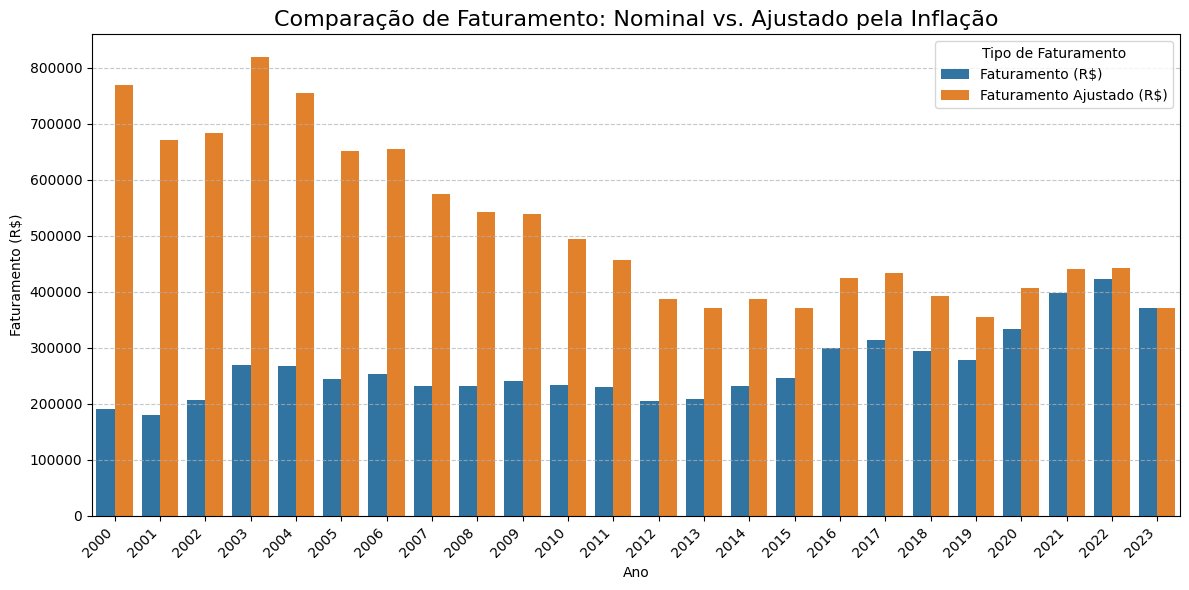

In [62]:
df_long = pd.melt(melted_faturamento_br, id_vars=['Ano'],
                  value_vars=['Faturamento (R$)', 'Faturamento Ajustado (R$)'],
                  var_name='Tipo de Faturamento',
                  value_name='Valor (R$)')

# Crie o gráfico de barras
plt.figure(figsize=(12, 6))

sns.barplot(data=df_long, x='Ano', y='Valor (R$)', hue='Tipo de Faturamento')

# Adicione títulos e rótulos
plt.title('Comparação de Faturamento: Nominal vs. Ajustado pela Inflação', fontsize=16)
plt.xlabel('Ano')
plt.ylabel('Faturamento (R$)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ajuste os rótulos do eixo X para que sejam visíveis
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Com o Faturamento ajustado pelo IPCA **2003** acaba sendo o ano com maior faturamento, e se torna possível visualizar que apesar do valor bruto faturado com a venda de mel ter aumentado, a verdade é que se esta ganhando menos.

#### Em qual ano o Brasil mais produziu mel?

##### Extração

Vamos repetir as operações anteriores

In [63]:
producao_br = pd.read_csv('data/producao mel/Producao Kg - Mel de Abelha - Brasil - 2000 2023.csv')
producao_br.info()
display(producao_br)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 27 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Sigla   1 non-null      object
 1   Código  1 non-null      int64 
 2   Brasil  1 non-null      object
 3   2000    1 non-null      int64 
 4   2001    1 non-null      int64 
 5   2002    1 non-null      int64 
 6   2003    1 non-null      int64 
 7   2004    1 non-null      int64 
 8   2005    1 non-null      int64 
 9   2006    1 non-null      int64 
 10  2007    1 non-null      int64 
 11  2008    1 non-null      int64 
 12  2009    1 non-null      int64 
 13  2010    1 non-null      int64 
 14  2011    1 non-null      int64 
 15  2012    1 non-null      int64 
 16  2013    1 non-null      int64 
 17  2014    1 non-null      int64 
 18  2015    1 non-null      int64 
 19  2016    1 non-null      int64 
 20  2017    1 non-null      int64 
 21  2018    1 non-null      int64 
 22  2019    1 non-null      int64 

,Sigla,Código,Brasil,2000,2001,2002,2003,2004,2005,2006,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,BR,0,Brasil,21865144,22204675,24028652,30022404,32290462,33749666,36193868,...,38481416,37859193,39677393,41695747,42407352,46088931,52493135,55678534,62494156,64188949


In [64]:
melted_producao_br = pd.melt(producao_br.drop(columns=['Sigla', 'Código']), id_vars=['Brasil'], var_name='Ano', value_name='Produção (Kg)')
show_head_tail(melted_producao_br)

,Brasil,Ano,Produção (Kg)
0,Brasil,2000,21865144
1,Brasil,2001,22204675
2,Brasil,2002,24028652
3,Brasil,2003,30022404
4,Brasil,2004,32290462


,Brasil,Ano,Produção (Kg)
19,Brasil,2019,46088931
20,Brasil,2020,52493135
21,Brasil,2021,55678534
22,Brasil,2022,62494156
23,Brasil,2023,64188949


In [65]:
melted_producao_br['Ano'] = melted_faturamento_br['Ano'].astype(int)

##### Resultado

In [66]:
show_max(melted_producao_br,'Produção (Kg)')
show_min(melted_producao_br,'Produção (Kg)')

Máximo valor em Produção (Kg)


,Brasil,Ano,Produção (Kg)
23,Brasil,2023,64188949


Mínimo valor em Produção (Kg)


,Brasil,Ano,Produção (Kg)
0,Brasil,2000,21865144


**2023** Foi o ano que o Brasil mais Produziu Mel. E percebemos que não é o mesmo ano que teve o maior faturamento.

#### E em qual ano o mel teve seu maior preço?

Pare responder essa pergunta vamos unir as duas tabelas anteriores. Estaremos levando me conta o faturamento ajustado para os cálculos.

In [67]:
mel_br = melted_producao_br.merge(melted_faturamento_br, on=['Brasil', 'Ano'],how='inner')
show_head_tail(mel_br)

,Brasil,Ano,Produção (Kg),Faturamento (R$),fator_ajuste,Faturamento Ajustado (R$)
0,Brasil,2000,21865144,191235.448330,4.023398,769416.339531
1,Brasil,2001,22204675,179290.160265,3.736667,669947.680919
2,Brasil,2002,24028652,205953.340512,3.320588,683886.292978
3,Brasil,2003,30022404,269407.150088,3.038036,818468.514089
4,Brasil,2004,32290462,267114.750166,2.823466,754189.520224


,Brasil,Ano,Produção (Kg),Faturamento (R$),fator_ajuste,Faturamento Ajustado (R$)
19,Brasil,2019,46088931,278263.994179,1.273111,354261.014774
20,Brasil,2020,52493135,334416.942334,1.218085,407348.184815
21,Brasil,2021,55678534,397418.252929,1.106736,439837.179171
22,Brasil,2022,62494156,422375.012785,1.046212,441893.764660
23,Brasil,2023,64188949,371282.235818,1.000000,371282.235818


In [68]:
show_max(mel_br,'Produção (Kg)')
show_max(mel_br,'Faturamento Ajustado (R$)')

Máximo valor em Produção (Kg)


,Brasil,Ano,Produção (Kg),Faturamento (R$),fator_ajuste,Faturamento Ajustado (R$)
23,Brasil,2023,64188949,371282.235818,1.0,371282.235818


Máximo valor em Faturamento Ajustado (R$)


,Brasil,Ano,Produção (Kg),Faturamento (R$),fator_ajuste,Faturamento Ajustado (R$)
3,Brasil,2003,30022404,269407.150088,3.038036,818468.514089


Aqui criamo o dado que faltava, o preço médio por kilograma.

In [69]:
mel_br['Preço do mel por Kg produzido'] = mel_br['Faturamento Ajustado (R$)']/mel_br['Produção (Kg)']
show_head_tail(mel_br)
show_max(mel_br,'Preço do mel por Kg produzido')

,Brasil,Ano,Produção (Kg),Faturamento (R$),fator_ajuste,Faturamento Ajustado (R$),Preço do mel por Kg produzido
0,Brasil,2000,21865144,191235.448330,4.023398,769416.339531,0.035189
1,Brasil,2001,22204675,179290.160265,3.736667,669947.680919,0.030171
2,Brasil,2002,24028652,205953.340512,3.320588,683886.292978,0.028461
3,Brasil,2003,30022404,269407.150088,3.038036,818468.514089,0.027262
4,Brasil,2004,32290462,267114.750166,2.823466,754189.520224,0.023356


,Brasil,Ano,Produção (Kg),Faturamento (R$),fator_ajuste,Faturamento Ajustado (R$),Preço do mel por Kg produzido
19,Brasil,2019,46088931,278263.994179,1.273111,354261.014774,0.007686
20,Brasil,2020,52493135,334416.942334,1.218085,407348.184815,0.007760
21,Brasil,2021,55678534,397418.252929,1.106736,439837.179171,0.007900
22,Brasil,2022,62494156,422375.012785,1.046212,441893.764660,0.007071
23,Brasil,2023,64188949,371282.235818,1.000000,371282.235818,0.005784


Máximo valor em Preço do mel por Kg produzido


,Brasil,Ano,Produção (Kg),Faturamento (R$),fator_ajuste,Faturamento Ajustado (R$),Preço do mel por Kg produzido
0,Brasil,2000,21865144,191235.44833,4.023398,769416.339531,0.035189


**2003** foi o ano em que o mel teve seu maior preço por kg, ou seja, mesmo que com o passar do tempo tenha se produzido mais e faturado mais, isso não implica que o preço do mel valorizou. Gráfico abaixo deve demonstrar melhor essa comparação.

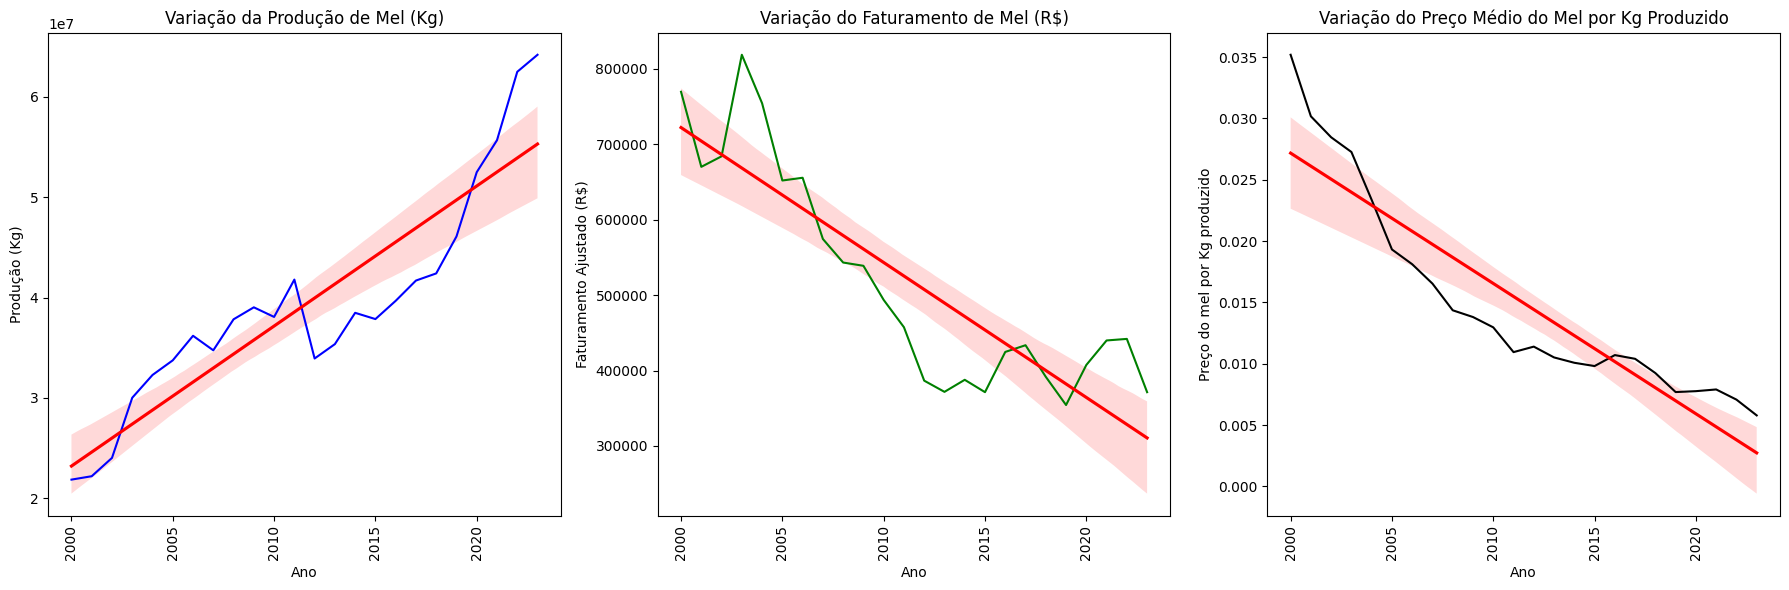

In [70]:
#Convertendo ano para numérico
mel_br['Ano'] = pd.to_numeric(mel_br['Ano'])

# Criar a figura e os 3 subplots lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Gráfico 1: Produção (Kg) com linha de tendência
sns.lineplot(data=mel_br, x='Ano', y='Produção (Kg)', ax=axes[0], color='blue')
sns.regplot(data=mel_br, x='Ano', y='Produção (Kg)', ax=axes[0], color='red', scatter=False, ci=95)
axes[0].set_title('Variação da Produção de Mel (Kg)')
axes[0].set_ylabel('Produção (Kg)')
axes[0].tick_params(axis='x', rotation=90)

# Gráfico 2: Faturamento Ajustado (R$) com linha de tendência
sns.lineplot(data=mel_br, x='Ano', y='Faturamento Ajustado (R$)', ax=axes[1], color='green')
sns.regplot(data=mel_br, x='Ano', y='Faturamento Ajustado (R$)', ax=axes[1], color='red', scatter=False, ci=95)
axes[1].set_title('Variação do Faturamento de Mel (R$)')
axes[1].set_ylabel('Faturamento Ajustado (R$)')
axes[1].tick_params(axis='x', rotation=90)

# Gráfico 3: Preço por Kg com linha de tendência
sns.lineplot(data=mel_br, x='Ano', y='Preço do mel por Kg produzido', ax=axes[2], color='black')
sns.regplot(data=mel_br, x='Ano', y='Preço do mel por Kg produzido', ax=axes[2], color='red', scatter=False, ci=95)
axes[2].set_title('Variação do Preço Médio do Mel por Kg Produzido')
axes[2].set_ylabel('Preço do mel por Kg produzido')
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

Com ajuda dos gráficos e suas linhas de tendencia conseguimos ver que apesar da produção do mel ter aumentado, ele é uma produto que tem passado por desvalorização com passar do tempo desdo o inicio do seculo. E apesar de ter tido uma valorização no período de 2016 e 2022, ele não alcançou mais o preço de 2003.

Pontos interessantes nos gráficos são:
1. O declínio da produção no período de 2012, que conforme a noticia do [Agrolink](https://www.agrolink.com.br/noticias/ibge--seca-faz-producao-nacional-de-mel-cair-19--em-2012_184745.html) foi causada pelo período de seca que ocorreu esse ano, e que a recuperação desse período de seca nos anos seguintes pode ter ocasionado a valorização nos anos seguinte, começando em 2013.
2. O outro declínio que aconteceu em 2019, porem esse não estando relacionado a produção de mel, permitindo assim concluir que o o valor do mel e as vendas não são unicamente influenciadas pela produção.


### Regiões

#### Produção

Nesta sessão estaremos utilizando o dataset separado por regiões, que possui a mesma fonte do nacional

In [71]:
producao_rg = pd.read_csv('data/producao mel/Producao Kg - Mel de Abelha - Regiões - 2000 2023.csv', delimiter=',', header=1)
producao_rg

,Sigla,Código,Região,2000,2001,2002,2003,2004,2005,2006,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,CO,5,Região Centro-oeste,631704,670833,683466,851928,916724,1097459,1189814,...,1682835,1587185,1699572,1971951,1529281,1794364,1856422,1731791,1508226,1801330
1,N,1,Região Norte,301696,317515,371143,509863,518834,653467,673729,...,1051946,948348,905534,802915,890099,1023003,999484,1129658,1252765,1282975
2,NE,2,Região Nordeste,3748108,3799504,5560006,7967658,10401191,10910916,12102924,...,10555158,12305251,10458385,12806050,14126096,15588516,19338339,20244963,24625523,25624482
3,S,4,Região Sul,12670098,12730601,12277442,15357099,15266363,15815522,16422483,...,16462708,14119128,17146509,16480865,16627518,17833466,20391853,22204521,22693682,21833880
4,SE,3,Região Sudeste,4513538,4686222,5136595,5335856,5187350,5272302,5804918,...,8728769,8899281,9467393,9633966,9234358,9849582,9907037,10367601,12413960,13646282


In [72]:
melted_faturamento_rg = pd.melt(producao_rg, id_vars=['Sigla','Código','Região'],var_name='Ano', value_name='Produção (Kg)')
show_head_tail(melted_faturamento_rg)

,Sigla,Código,Região,Ano,Produção (Kg)
0,CO,5,Região Centro-oeste,2000,631704
1,N,1,Região Norte,2000,301696
2,NE,2,Região Nordeste,2000,3748108
3,S,4,Região Sul,2000,12670098
4,SE,3,Região Sudeste,2000,4513538


,Sigla,Código,Região,Ano,Produção (Kg)
115,CO,5,Região Centro-oeste,2023,1801330
116,N,1,Região Norte,2023,1282975
117,NE,2,Região Nordeste,2023,25624482
118,S,4,Região Sul,2023,21833880
119,SE,3,Região Sudeste,2023,13646282


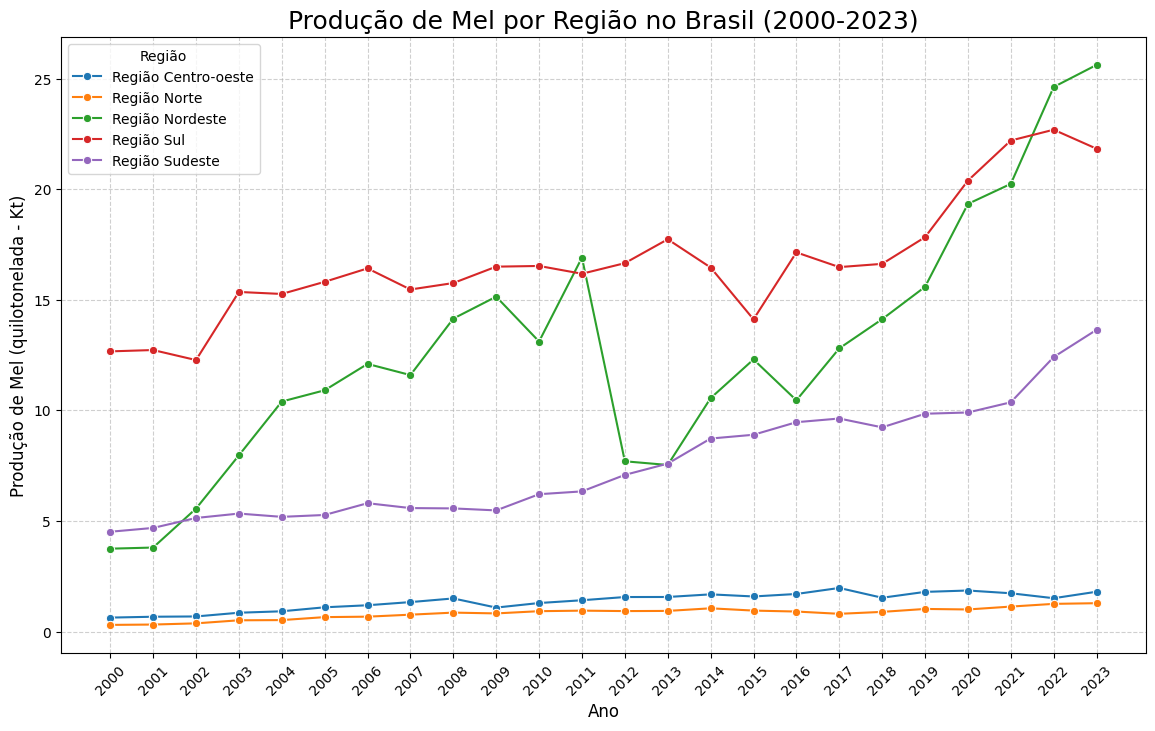

In [73]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.figure(figsize=(14, 8))
sns.lineplot(data=melted_faturamento_rg, x='Ano', y='Produção (Kg)', hue='Região', marker='o')

# Adicione título e rótulos
plt.title('Produção de Mel por Região no Brasil (2000-2023)', fontsize=18)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Produção de Mel (quilotonelada - Kt)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Formate os rótulos do eixo Y para mostrar em milhões
def millions_formatter(x, pos):
    """Função para formatar os valores do eixo Y em milhões."""
    return f'{x / 1e6:,.0f}'

plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(millions_formatter))

# Adicione a legenda
plt.legend(title='Região', loc='upper left')

# Rotacione os rótulos do eixo X para melhor leitura
plt.xticks(melted_faturamento_rg['Ano'].unique(), rotation=45)

plt.show()

O gráfico acima nos permite visualizar quais são as principais regiões responsáveis pela produção de mel no Brasil desde o início do século XXI. Como esperado, a **Região Sul**, **Nordeste** e **Sudeste** se destacam, sendo as que mais contribuem para o volume total de mel produzido no país.

No entanto, a análise do gráfico revela mais do que apenas a liderança. É possível observar o comportamento distinto de cada uma dessas regiões ao longo do tempo:

* **Região Sul**: Apresenta um crescimento constante na produção, com uma curva ascendente que reflete o fortalecimento do setor apícola na região. É notável que, apesar de flutuações, a tendência geral é de alta. Teve um declínio em 2015 segundo pesquisa, 2 eventos ocorreram esse ano que estão fortemente atreladas a esse declínio:
    * O [El Nino](https://www.climatempo.com.br/noticia/2016/09/22/o-legado-do-el-nino-2015-0199) que é um fenômeno climático natural que aquece as águas do Oceano Pacífico Equatorial.No Brasil, ele causa, principalmente: Secas severas nas regiões Norte e Nordeste, e Aumento de chuvas e inundações na região Sul.
    * A [utilização incorreta de um defensivos agrícolas](https://gauchazh.clicrbs.com.br/campo-e-lavoura/noticia/2015/01/diminuicao-de-250-mil-colmeias-afeta-a-producao-de-mel-no-estado-4679610.html) que resultou na morte de 250 mil colmeias no Rio Grande do Sul.

* **Região Nordeste**: Tem um crescimento significativo, mas com uma alta volatilidade. É possível observar um crescimento inicial forte, seguido por uma queda brusca entre 2011 e 2012, e uma recuperação impressionante a partir de 2017, superando as outras regiões. Essa dinâmica sugere uma sensibilidade maior a fatores externos, como mudanças climáticas.

* **Região Sudeste**:  Apresenta um crescimento constante e estável, sem as grandes oscilações vistas em outras regiões. A produção tem uma tendência de alta clara, mostrando um desenvolvimento sólido e menos suscetível a flutuações.

Além disso, as regiões de menor produção, **Norte** e **Centro-Oeste**, se mantêm em patamares significativamente mais baixos. Ambas apresentam uma produção relativamente estável, sem as grandes oscilações ou tendências de crescimento acentuado vistas nas demais regiões.

Em resumo, o gráfico mostra que, embora três regiões dominem a produção, a dinâmica e a tendência de crescimento de cada uma são únicas, refletindo as particularidades de seus ecossistemas e do cenário econômico ao qual estão expostas.

#### Faturamento

In [74]:
faturamento_rg = pd.read_csv('data/faturamento mel/Faturamento R$ - Mel de Abelha - Regiões - 2000 2023.csv', delimiter=',', header=1)
faturamento_rg

,Sigla,Código,Região,2000,2001,2002,2003,2004,2005,2006,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,CO,5,Região Centro-oeste,8975.625259,9148.691660,9291.656644,10968.107158,11783.065304,13488.132567,15080.182058,...,14266.737278,14459.926110,16662.098564,18997.613538,15137.275784,16286.338202,17524.290008,16893.288991,15920.077933,18176.427594
1,N,1,Região Norte,4751.934399,4666.124770,4557.490143,5391.639742,5139.734452,5618.496940,5912.713869,...,10987.010601,10171.668203,9564.609178,7950.041715,8623.603358,9340.512187,10188.025262,12477.758842,13356.664623,14557.987244
2,NE,2,Região Nordeste,24145.696119,19129.651439,35948.889527,61244.564958,64170.959974,53510.933095,58623.298411,...,56578.604743,70387.642217,68846.535187,84191.994260,78691.112643,67982.791843,103919.335267,142004.644618,157642.179321,125139.568663
3,S,4,Região Sul,102407.008110,97185.554449,100390.166367,130887.965882,127272.558481,118434.348199,115500.669009,...,94547.748198,90632.224563,134061.221363,131810.859424,127283.940500,121835.137283,136856.535967,150592.031511,151431.427013,137003.146652
4,SE,3,Região Sudeste,50955.184443,49160.137947,55765.137831,60914.872349,58748.431954,52944.192749,57949.715150,...,55998.050335,60661.738869,70266.286818,71732.115150,65190.599822,62818.652796,65928.755829,75450.528968,84024.233937,76404.696801


In [75]:
melted_faturamento_rg = pd.melt(faturamento_rg, id_vars=['Sigla','Código','Região'],var_name='Ano', value_name='Faturamento (R$)')
show_head_tail(melted_faturamento_rg)

,Sigla,Código,Região,Ano,Faturamento (R$)
0,CO,5,Região Centro-oeste,2000,8975.625259
1,N,1,Região Norte,2000,4751.934399
2,NE,2,Região Nordeste,2000,24145.696119
3,S,4,Região Sul,2000,102407.008110
4,SE,3,Região Sudeste,2000,50955.184443


,Sigla,Código,Região,Ano,Faturamento (R$)
115,CO,5,Região Centro-oeste,2023,18176.427594
116,N,1,Região Norte,2023,14557.987244
117,NE,2,Região Nordeste,2023,125139.568663
118,S,4,Região Sul,2023,137003.146652
119,SE,3,Região Sudeste,2023,76404.696801


In [76]:
melted_faturamento_rg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Sigla             120 non-null    object 
 1   Código            120 non-null    int64  
 2   Região            120 non-null    object 
 3   Ano               120 non-null    object 
 4   Faturamento (R$)  120 non-null    float64
dtypes: float64(1), int64(1), object(3)
memory usage: 4.8+ KB


In [77]:
melted_faturamento_rg['Ano'] = melted_faturamento_rg['Ano'].astype(int)
melted_faturamento_rg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Sigla             120 non-null    object 
 1   Código            120 non-null    int64  
 2   Região            120 non-null    object 
 3   Ano               120 non-null    int64  
 4   Faturamento (R$)  120 non-null    float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.8+ KB


In [78]:
dicionario_ajuste = df_ipca.set_index('Ano')['fator_ajuste'].to_dict()
melted_faturamento_rg['fator_ajuste'] = melted_faturamento_rg['Ano'].map(dicionario_ajuste)
melted_faturamento_rg['Faturamento Ajustado (R$)'] = melted_faturamento_rg['Faturamento (R$)'] * melted_faturamento_rg['fator_ajuste']
melted_faturamento_rg = melted_faturamento_rg.drop(columns=['fator_ajuste'])

display(melted_faturamento_rg)

,Sigla,Código,Região,Ano,Faturamento (R$),Faturamento Ajustado (R$)
0,CO,5,Região Centro-oeste,2000,8975.625259,36112.513616
1,N,1,Região Norte,2000,4751.934399,19118.923834
2,NE,2,Região Nordeste,2000,24145.696119,97147.747898
3,S,4,Região Sul,2000,102407.008110,412024.161894
4,SE,3,Região Sudeste,2000,50955.184443,205012.992291
...,...,...,...,...,...,...
115,CO,5,Região Centro-oeste,2023,18176.427594,18176.427594
116,N,1,Região Norte,2023,14557.987244,14557.987244
117,NE,2,Região Nordeste,2023,125139.568663,125139.568663
118,S,4,Região Sul,2023,137003.146652,137003.146652


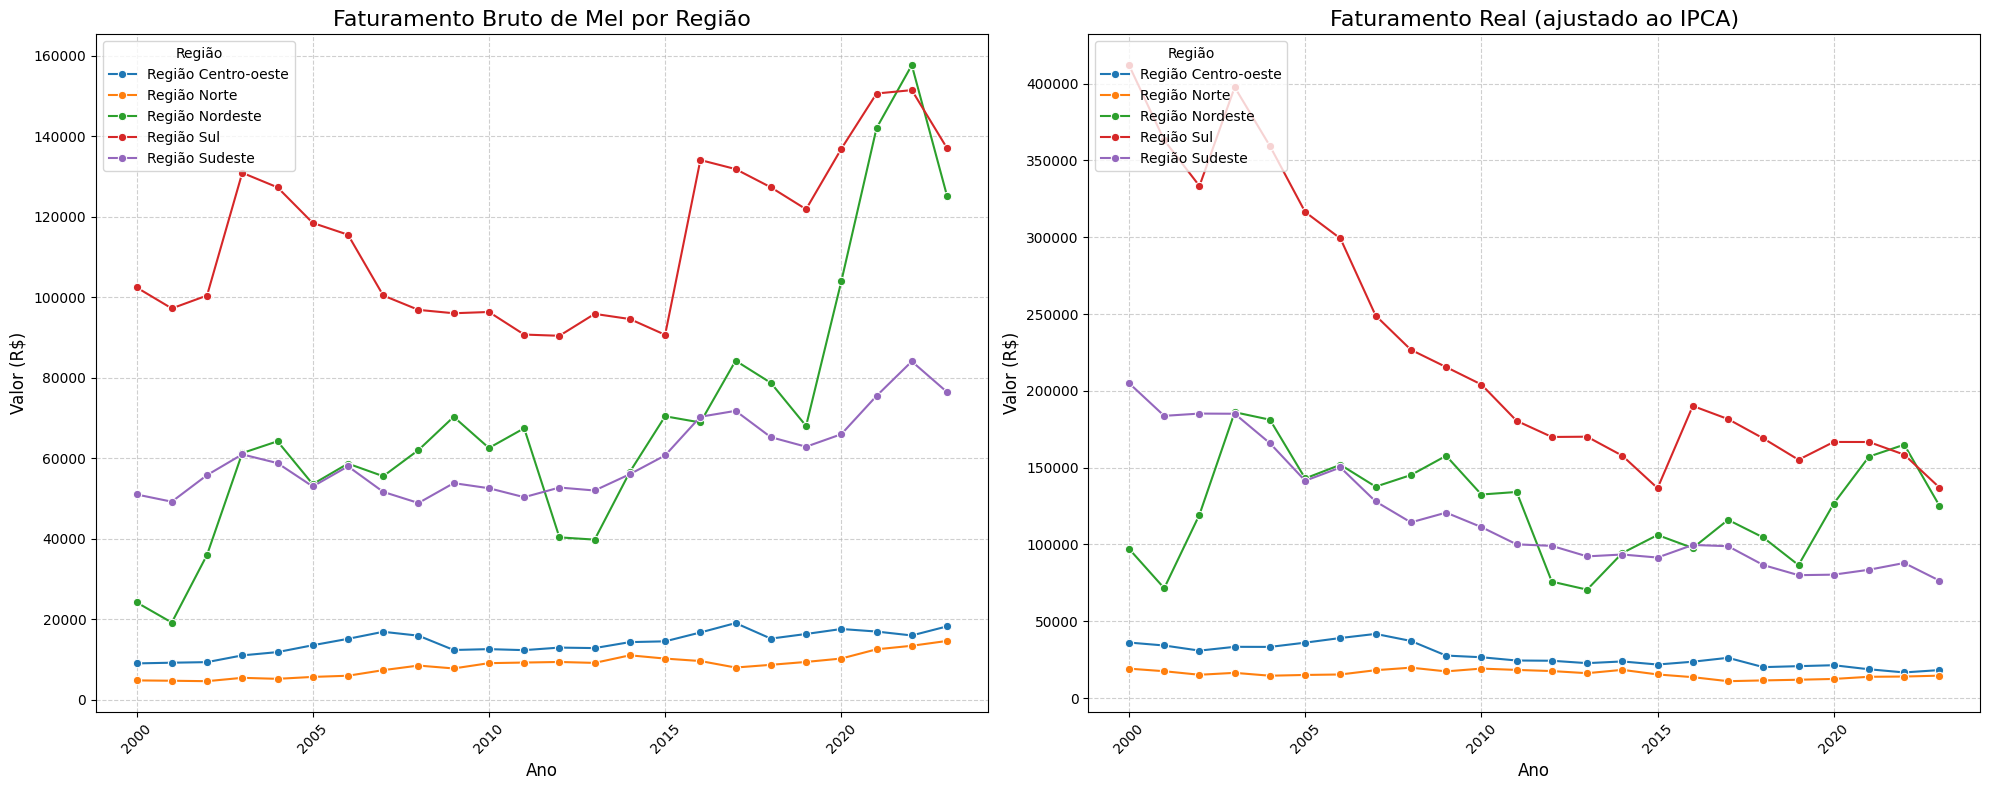

In [79]:

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- Gráfico 1: Faturamento Bruto (Nominal) ---
sns.lineplot(
    data=melted_faturamento_rg,
    x='Ano',
    y='Faturamento (R$)',
    hue='Região',
    marker='o',
    ax=axes[0]
)
axes[0].set_title('Faturamento Bruto de Mel por Região', fontsize=16)
axes[0].set_xlabel('Ano', fontsize=12)
axes[0].set_ylabel('Valor (R$)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].tick_params(axis='x', rotation=45)

# --- Gráfico 2: Faturamento Ajustado (Real) ---
sns.lineplot(
    data=melted_faturamento_rg,
    x='Ano',
    y='Faturamento Ajustado (R$)',
    hue='Região',
    marker='o',
    ax=axes[1]
)
axes[1].set_title('Faturamento Real (ajustado ao IPCA)', fontsize=16)
axes[1].set_xlabel('Ano', fontsize=12)
axes[1].set_ylabel('Valor (R$)', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Região', loc='upper left')


plt.tight_layout()
plt.show()


Os gráficos de faturamento bruto e ajustado confirmam que as mesmas três regiões — **Sul, Sudeste e Nordeste** — que lideram a produção também dominam o faturamento do mel no Brasil.

No entanto, uma observação crucial é que, apesar da produção do Nordeste superar a do Sul em alguns anos, o faturamento de ambas as regiões se mantém em patamares próximos. Isso sugere que, embora o volume de mel produzido no Nordeste seja significativo, o preço de venda por quilo pode ser menor do que o do Sul, o que o torna menos valorizado no mercado.

Em contrapartida, as flutuações no faturamento da Região Sudeste são notáveis. A queda abrupta em 2012 e a recuperação em 2015 são consistentes com as tendências observadas na análise de produção e preço para o Brasil como um todo. A volatilidade do faturamento no Nordeste, por sua vez, reflete a instabilidade de sua produção, que pode ser mais suscetível a fatores externos como as mudanças climáticas.

Essa análise demonstra que a relação entre produção e faturamento não é direta. A lucratividade do mel é influenciada não apenas pelo volume produzido, mas também pelo preço de mercado, que varia significativamente entre as regiões.

### Estados

* A partir desta sessão estaremos analisando apenas os fatores da produção de mel
* Para essa sessão iremos considerar apenas os estados da região **Sul, Nordeste e Sudeste**, pois com base nos resultados das sessões anteriores são os principais contribuintes para a produção e faturamento de mel no pais.
* E o dataset com estados não alinha possui as regiões de cadas um, então esses valores serão colocados por código utilizando o dicionario abaixo.

In [80]:
#dicionario com a lista de região de cada estado
mapa_regioes = {
    'AC': 'Região Norte',
    'AL': 'Região Nordeste',
    'AP': 'Região Norte',
    'AM': 'Região Norte',
    'BA': 'Região Nordeste',
    'CE': 'Região Nordeste',
    'DF': 'Região Centro-oeste',
    'ES': 'Região Sudeste',
    'GO': 'Região Centro-oeste',
    'MA': 'Região Nordeste',
    'MT': 'Região Centro-oeste',
    'MS': 'Região Centro-oeste',
    'MG': 'Região Sudeste',
    'PA': 'Região Norte',
    'PB': 'Região Nordeste',
    'PR': 'Região Sul',
    'PE': 'Região Nordeste',
    'PI': 'Região Nordeste',
    'RJ': 'Região Sudeste',
    'RN': 'Região Nordeste',
    'RS': 'Região Sul',
    'RO': 'Região Norte',
    'RR': 'Região Norte',
    'SC': 'Região Sul',
    'SP': 'Região Sudeste',
    'SE': 'Região Nordeste',
    'TO': 'Região Norte'
}

#### Produção

In [81]:
producao_es = pd.read_csv('data/producao mel/Producao Kg - Mel de Abelha - Estados - 2000 2023.csv', delimiter=',', header=1)
producao_es

,Sigla,Código,Estado,2000,2001,2002,2003,2004,2005,2006,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,Unnamed: 27
0,AC,12,Acre,1800.0,3305.0,3300.0,4483.0,4927.0,4279.0,3704.0,...,9567,4752,5760,5803,4914,4574,6092,8578,9003,NaN
1,AL,27,Alagoas,13941.0,21200.0,14513.0,85696.0,116098.0,183946.0,163885.0,...,142823,168889,216311,264748,331471,372098,403386,423263,515190,NaN
2,AM,13,Amazonas,498.0,505.0,600.0,1018.0,1043.0,1043.0,1085.0,...,35655,33310,30838,32577,32542,32898,34686,33532,34377,NaN
3,AP,16,Amapá,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10468,11379,13458,14782,15585,16521,18199,18245,19378,NaN
4,BA,29,Bahia,520908.0,688105.0,873278.0,1418628.0,1494713.0,1775414.0,2046930.0,...,4595530,3579469,3407361,3039843,3708261,5017609,4588657,5029007,4774681,NaN
5,CE,23,Ceará,654791.0,671873.0,1373377.0,1895918.0,2933133.0,2311626.0,3053053.0,...,1357080,1149390,1776231,2113192,2677489,3897743,3754811,5398805,5703654,NaN
6,DF,53,Distrito Federal,20000.0,14060.0,19060.0,24500.0,26430.0,27479.0,31478.0,...,24558,17660,14325,11069,13826,21944,22423,36739,32532,NaN
7,ES,32,Espírito Santo,176655.0,179725.0,275957.0,312455.0,352626.0,333494.0,403224.0,...,870240,544853,583029,620407,660758,687504,708901,804348,811258,NaN
8,GO,52,Goiás,117371.0,128222.0,155133.0,178845.0,224616.0,244580.0,308005.0,...,320860,432722,319212,337655,331178,329167,366191,316321,402259,NaN
9,MA,21,Maranhão,132478.0,133026.0,158076.0,285863.0,436161.0,517533.0,558775.0,...,1286316,1710718,2355873,2261672,2337026,2477212,2381960,2572768,3186374,NaN


In [82]:
producao_es.drop(columns=['Unnamed: 27'], inplace=True)
producao_es['Região'] = producao_es['Sigla'].map(mapa_regioes)
producao_es

,Sigla,Código,Estado,2000,2001,2002,2003,2004,2005,2006,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,Região
0,AC,12,Acre,1800.0,3305.0,3300.0,4483.0,4927.0,4279.0,3704.0,...,9567,4752,5760,5803,4914,4574,6092,8578,9003,Região Norte
1,AL,27,Alagoas,13941.0,21200.0,14513.0,85696.0,116098.0,183946.0,163885.0,...,142823,168889,216311,264748,331471,372098,403386,423263,515190,Região Nordeste
2,AM,13,Amazonas,498.0,505.0,600.0,1018.0,1043.0,1043.0,1085.0,...,35655,33310,30838,32577,32542,32898,34686,33532,34377,Região Norte
3,AP,16,Amapá,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10468,11379,13458,14782,15585,16521,18199,18245,19378,Região Norte
4,BA,29,Bahia,520908.0,688105.0,873278.0,1418628.0,1494713.0,1775414.0,2046930.0,...,4595530,3579469,3407361,3039843,3708261,5017609,4588657,5029007,4774681,Região Nordeste
5,CE,23,Ceará,654791.0,671873.0,1373377.0,1895918.0,2933133.0,2311626.0,3053053.0,...,1357080,1149390,1776231,2113192,2677489,3897743,3754811,5398805,5703654,Região Nordeste
6,DF,53,Distrito Federal,20000.0,14060.0,19060.0,24500.0,26430.0,27479.0,31478.0,...,24558,17660,14325,11069,13826,21944,22423,36739,32532,Região Centro-oeste
7,ES,32,Espírito Santo,176655.0,179725.0,275957.0,312455.0,352626.0,333494.0,403224.0,...,870240,544853,583029,620407,660758,687504,708901,804348,811258,Região Sudeste
8,GO,52,Goiás,117371.0,128222.0,155133.0,178845.0,224616.0,244580.0,308005.0,...,320860,432722,319212,337655,331178,329167,366191,316321,402259,Região Centro-oeste
9,MA,21,Maranhão,132478.0,133026.0,158076.0,285863.0,436161.0,517533.0,558775.0,...,1286316,1710718,2355873,2261672,2337026,2477212,2381960,2572768,3186374,Região Nordeste


In [83]:
# Filtrar apenas estados das regiões Sul, Sudeste e Nordeste
estados_pesquisa = producao_es[producao_es['Região'].isin(['Região Sul', 'Região Sudeste', 'Região Nordeste'])]
display(estados_pesquisa)

,Sigla,Código,Estado,2000,2001,2002,2003,2004,2005,2006,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,Região
1,AL,27,Alagoas,13941.0,21200.0,14513.0,85696.0,116098.0,183946.0,163885.0,...,142823,168889,216311,264748,331471,372098,403386,423263,515190,Região Nordeste
4,BA,29,Bahia,520908.0,688105.0,873278.0,1418628.0,1494713.0,1775414.0,2046930.0,...,4595530,3579469,3407361,3039843,3708261,5017609,4588657,5029007,4774681,Região Nordeste
5,CE,23,Ceará,654791.0,671873.0,1373377.0,1895918.0,2933133.0,2311626.0,3053053.0,...,1357080,1149390,1776231,2113192,2677489,3897743,3754811,5398805,5703654,Região Nordeste
7,ES,32,Espírito Santo,176655.0,179725.0,275957.0,312455.0,352626.0,333494.0,403224.0,...,870240,544853,583029,620407,660758,687504,708901,804348,811258,Região Sudeste
9,MA,21,Maranhão,132478.0,133026.0,158076.0,285863.0,436161.0,517533.0,558775.0,...,1286316,1710718,2355873,2261672,2337026,2477212,2381960,2572768,3186374,Região Nordeste
10,MG,31,Minas Gerais,2100982.0,2068024.0,2408189.0,2194385.0,2134370.0,2207925.0,2482174.0,...,4414854,4906589,4560848,4077462,4226823,4103316,4584133,6164784,6862976,Região Sudeste
14,PB,25,Paraíba,30036.0,32364.0,41228.0,58643.0,73031.0,87607.0,263964.0,...,191612,156563,156438,199227,199603,278910,310721,357594,364192,Região Nordeste
15,PE,26,Pernambuco,344325.0,320109.0,575016.0,653418.0,883196.0,1028772.0,1161579.0,...,385680,372100,255809,616426,769814,938426,1248305,1658340,1203900,Região Nordeste
16,PI,22,Piauí,1862739.0,1741078.0,2221510.0,3146358.0,3894437.0,4497392.0,4195910.0,...,3966914,3048800,4404654,5224833,5024344,5672514,6875615,8321923,8829805,Região Nordeste
17,PR,41,Paraná,2870955.0,2925432.0,2843995.0,4068191.0,4348301.0,4462022.0,4612372.0,...,6287264,5993565,5962813,6307107,7202539,7890115,8418363,8799569,8488483,Região Sul


In [84]:
melted_producao_es = pd.melt(estados_pesquisa, id_vars=['Sigla','Código','Região','Estado'],var_name='Ano', value_name='Produção (Kg)')
show_head_tail(melted_producao_es)

,Sigla,Código,Região,Estado,Ano,Produção (Kg)
0,AL,27,Região Nordeste,Alagoas,2000,13941.0
1,BA,29,Região Nordeste,Bahia,2000,520908.0
2,CE,23,Região Nordeste,Ceará,2000,654791.0
3,ES,32,Região Sudeste,Espírito Santo,2000,176655.0
4,MA,21,Região Nordeste,Maranhão,2000,132478.0


,Sigla,Código,Região,Estado,Ano,Produção (Kg)
379,RN,24,Região Nordeste,Rio Grande do Norte,2023,886900.0
380,RS,43,Região Sul,Rio Grande do Sul,2023,9111304.0
381,SC,42,Região Sul,Santa Catarina,2023,4234093.0
382,SE,28,Região Nordeste,Sergipe,2023,159786.0
383,SP,35,Região Sudeste,São Paulo,2023,5561856.0


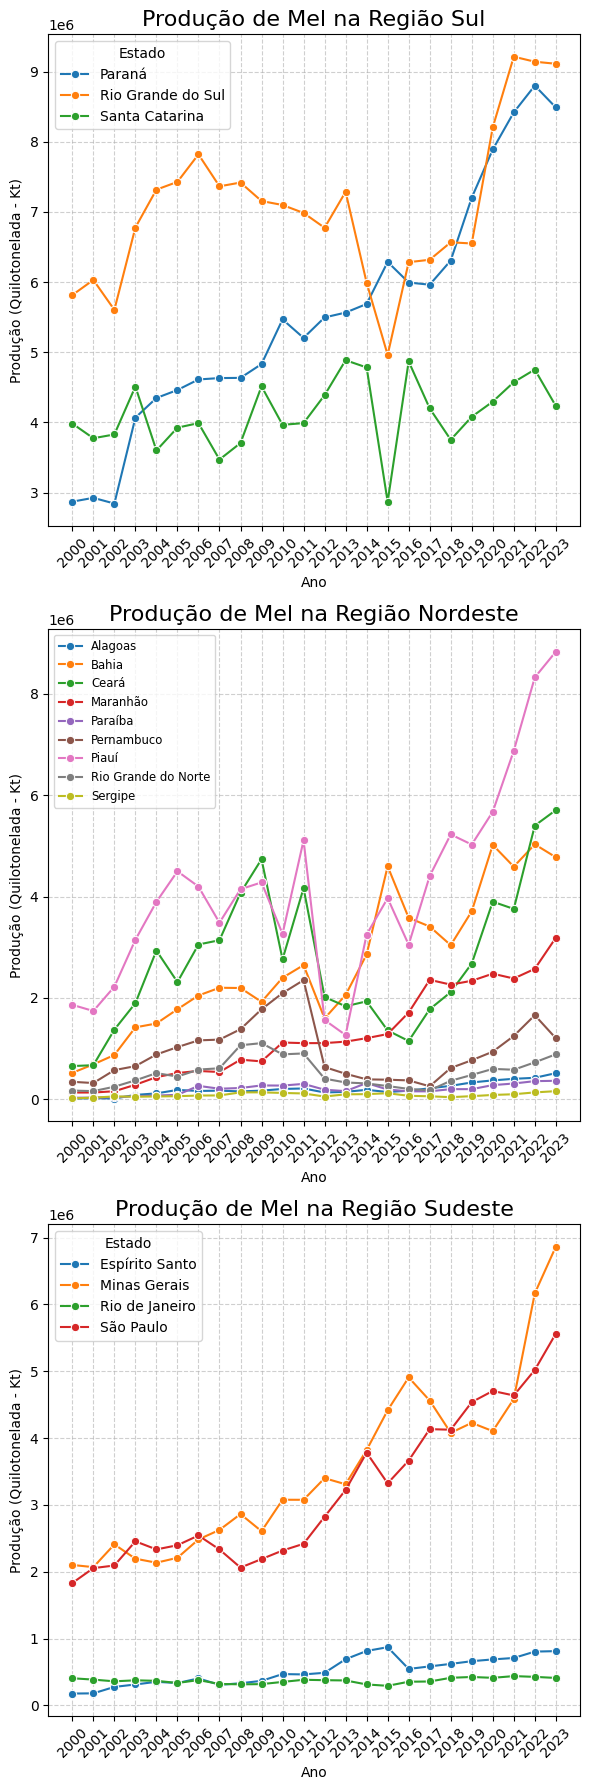

In [85]:
fig, axes = plt.subplots(3, 1, figsize=(6, 18))

# --- GRÁFICO 1: REGIÃO SUL ---
# Filtre o DataFrame para a Região Sul
df_sul = melted_producao_es[melted_producao_es['Região'] == 'Região Sul']

# Plote o gráfico
sns.lineplot(
    data=df_sul,
    x='Ano',
    y='Produção (Kg)',
    hue='Estado',
    marker='o',
    ax=axes[0]
)
axes[0].set_title('Produção de Mel na Região Sul', fontsize=16)
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Produção (Quilotonelada - Kt)')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].tick_params(axis='x', rotation=45)

# --- GRÁFICO 2: REGIÃO NORDESTE ---
# Filtre o DataFrame para a Região Nordeste
df_nordeste = melted_producao_es[melted_producao_es['Região'] == 'Região Nordeste']

# Plote o gráfico
sns.lineplot(
    data=df_nordeste,
    x='Ano',
    y='Produção (Kg)',
    hue='Estado',
    marker='o',
    ax=axes[1]
)
axes[1].set_title('Produção de Mel na Região Nordeste', fontsize=16)
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Produção (Quilotonelada - Kt)')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(loc='upper left', fontsize='small') # Legenda menor para evitar sobreposição

# --- GRÁFICO 3: REGIÃO SUDESTE ---
# Filtre o DataFrame para a Região Sudeste
df_sudeste = melted_producao_es[melted_producao_es['Região'] == 'Região Sudeste']

# Plote o gráfico
sns.lineplot(
    data=df_sudeste,
    x='Ano',
    y='Produção (Kg)',
    hue='Estado',
    marker='o',
    ax=axes[2]
)
axes[2].set_title('Produção de Mel na Região Sudeste', fontsize=16)
axes[2].set_xlabel('Ano')
axes[2].set_ylabel('Produção (Quilotonelada - Kt)')
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].tick_params(axis='x', rotation=45)

# Otimize o layout para evitar sobreposição de elementos
plt.tight_layout()
plt.show()

Análise Aprofundada da Produção por Estado
A análise detalhada por estado confirma que a produção de mel é muito mais *volátil* em nível estadual do que em nível regional. Dentro das três principais regiões produtoras, cada estado tem uma dinâmica própria, influenciada por fatores locais.

* **Região Sul**: O gráfico do **Sul** mostra um panorama de crescimento notável, com a produção do Paraná (linha azul) apresentando uma forte tendência de alta a partir de 2003. Em 2014, o **Paraná** alcançou um nível de produção muito próximo ao do **Rio Grande do Sul**, e tem se mantido competitivo desde então. O **Rio Grande do Sul e Santa Catarina** também exibem crescimento, mas com flutuações mais evidentes. O destaque, no entanto, fica para o acentuado declínio de produção em 2015. Esse evento pode ser atribuído a uma combinação de fatores: o intenso **El Niño** que causou chuvas torrenciais, prejudicando a florada e a atividade das abelhas, e o uso incorreto de **defensivos agrícolas** que resultou na morte em massa de colmeias na região.

* **Região Nordeste**: O impacto da **seca de 2012** é claramente visível, afetando os quatro maiores produtores de 2011: **Piauí, Ceará, Bahia e Pernambuco**. Os gráficos mostram uma queda acentuada na produção de todos esses estados no período. É notável que, em 2023, Pernambuco ainda não conseguiu recuperar o nível de produção que tinha antes da seca. A produção da Paraíba, por sua vez, manteve-se relativamente estável, sem um crescimento significativo, indicando a falta de avanço do setor no estado.

* **Região Sudeste**: A produção no Sudeste, liderada por Minas Gerais e São Paulo, mostra uma tendência de crescimento consistente e notável ao longo do tempo. Embora a produção total da região tenha flutuado em alguns anos, a análise por estado revela que os dois maiores produtores da região continuaram expandindo suas produções de mel de forma contínua.

## Biomas

In [86]:
biomas = pd.read_csv('data/biomas/Bioma_Predominante_por_Municipio_2024.csv',delimiter=';')
biomas

,Geocódigo,Nome do município,Sigla da UF,Bioma predominante
0,1100015,Alta Floresta D'Oeste,RO,Amazônia
1,1100023,Ariquemes,RO,Amazônia
2,1100031,Cabixi,RO,Amazônia
3,1100049,Cacoal,RO,Amazônia
4,1100056,Cerejeiras,RO,Amazônia
...,...,...,...,...
5567,5222005,Vianópolis,GO,Cerrado
5568,5222054,Vicentinópolis,GO,Cerrado
5569,5222203,Vila Boa,GO,Cerrado
5570,5222302,Vila Propício,GO,Cerrado


In [87]:
contagem_biomas = biomas.groupby(['Sigla da UF', 'Bioma predominante']).size().reset_index(name='Num de Municipios')

contagem_biomas = contagem_biomas.sort_values(by=['Sigla da UF', 'Num de Municipios'], ascending=[True, False])

top2_biomas_por_estado = contagem_biomas.groupby('Sigla da UF').head(2).reset_index(drop=True)

top2_biomas_por_estado['rank'] = top2_biomas_por_estado.groupby('Sigla da UF')['Num de Municipios'].rank(ascending=False, method='first')

tabela_final = top2_biomas_por_estado.pivot_table(
    index='Sigla da UF', 
    columns='rank', 
    values='Bioma predominante', 
    aggfunc='first'
).rename(columns={1.0: '1º Bioma Predominante', 2.0: '2º Bioma Predominante'})

tabela_final

rank,1º Bioma Predominante,2º Bioma Predominante
Sigla da UF,,
AC,Amazônia,NaN
AL,Mata Atlântica,Caatinga
AM,Amazônia,NaN
AP,Amazônia,NaN
BA,Caatinga,Mata Atlântica
CE,Caatinga,NaN
DF,Cerrado,NaN
ES,Mata Atlântica,NaN
GO,Cerrado,Mata Atlântica


In [88]:
tabela_final = tabela_final.reset_index().rename(columns={'Sigla da UF': 'Sigla'})

# 3. Anexe a tabela de biomas ao seu DataFrame de produção usando 'Estado' como chave
df_com_biomas = melted_producao_es.merge(
    tabela_final,
    on='Sigla',
    how='left'
)

# 4. Verifique o resultado
df_com_biomas.head()

,Sigla,Código,Região,Estado,Ano,Produção (Kg),1º Bioma Predominante,2º Bioma Predominante
0,AL,27,Região Nordeste,Alagoas,2000,13941.0,Mata Atlântica,Caatinga
1,BA,29,Região Nordeste,Bahia,2000,520908.0,Caatinga,Mata Atlântica
2,CE,23,Região Nordeste,Ceará,2000,654791.0,Caatinga,NaN
3,ES,32,Região Sudeste,Espírito Santo,2000,176655.0,Mata Atlântica,NaN
4,MA,21,Região Nordeste,Maranhão,2000,132478.0,Cerrado,Amazônia


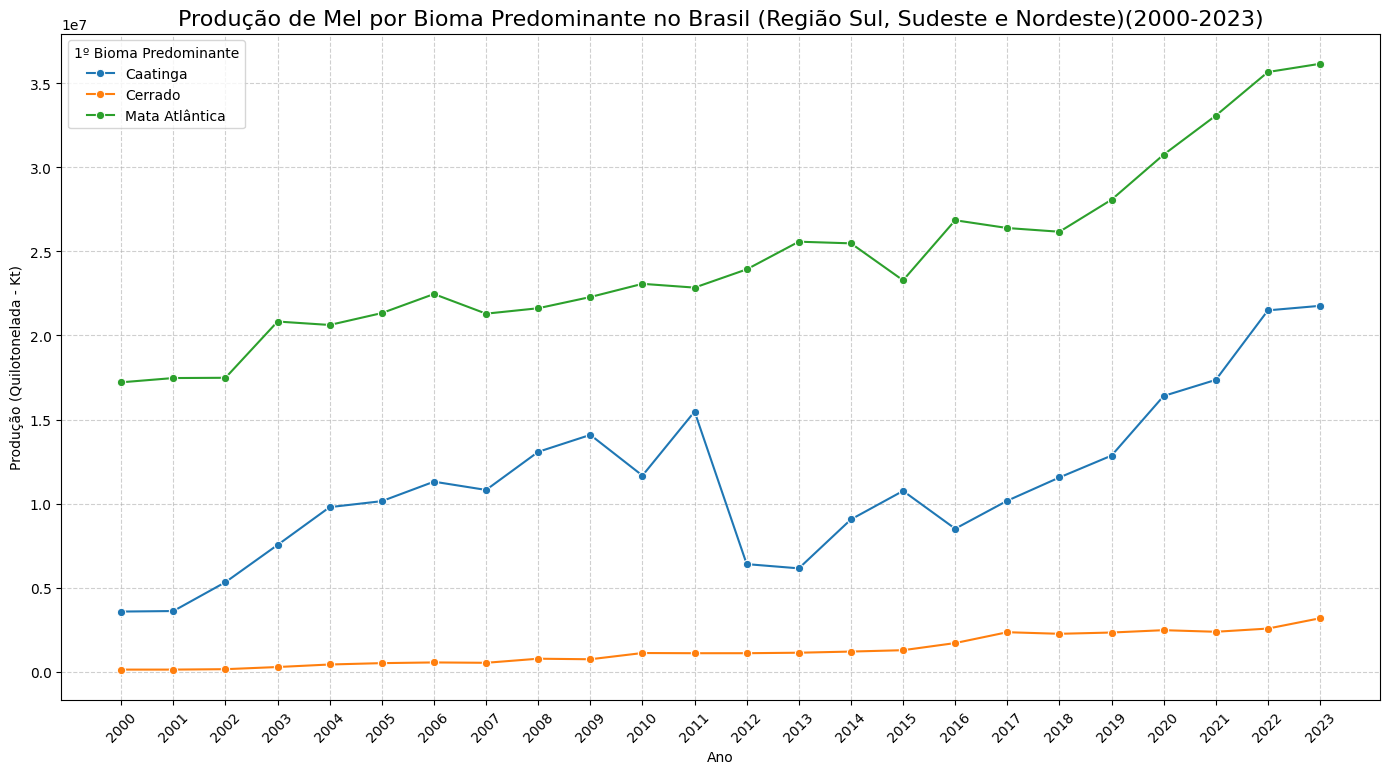

In [89]:
producao_por_bioma_anual = df_com_biomas.groupby(['Ano', '1º Bioma Predominante'])['Produção (Kg)'].sum().reset_index()

# 2. Crie o gráfico de linha para comparar a produção entre os biomas
plt.figure(figsize=(14, 8))
sns.lineplot(
    data=producao_por_bioma_anual,
    x='Ano',
    y='Produção (Kg)',
    hue='1º Bioma Predominante',
    marker='o'
)

# Adicione títulos e rótulos
plt.title('Produção de Mel por Bioma Predominante no Brasil (Região Sul, Sudeste e Nordeste)(2000-2023)', fontsize=16)
plt.xlabel('Ano')
plt.ylabel('Produção (Quilotonelada - Kt)')
plt.grid(True, linestyle='--', alpha=0.6)

# Ajuste os rótulos do eixo X para melhor visualização
plt.xticks(producao_por_bioma_anual['Ano'].unique(), rotation=45)

plt.tight_layout()
plt.show()

O gráfico acima nos permite aprofundar a análise da produção de mel, correlacionando-a com o bioma mais predominante de cada estado nas regiões Sul, Sudeste e Nordeste. As três linhas em destaque — Caatinga, Cerrado e Mata Atlântica — representam a produção total de mel dos estados dominados por esses biomas ao longo do tempo.

A análise da produção por bioma revela dinâmicas distintas que explicam as flutuações regionais:

Mata Atlântica (Região Sudeste e Sul): Este bioma apresenta a produção mais alta e estável. A linha da Mata Atlântica demonstra um crescimento constante e robusto, refletindo a importância e a resiliência do ecossistema para a apicultura.

Caatinga (Região Nordeste): A produção de mel na Caatinga, apesar de ter um nível menor, é marcada por uma volatilidade significativa. É possível observar uma forte queda na produção entre 2011 e 2012, um evento diretamente ligado à intensa seca que afetou a região naquele período.

Cerrado (Região Centro-Oeste e Sudeste): A produção do Cerrado se mantém em um patamar consistentemente mais baixo em comparação com a Mata Atlântica e a Caatinga, mas com uma leve e gradual tendência de crescimento.

Essa nova perspectiva demonstra que a produção de mel no Brasil não depende apenas da região, mas está intrinsecamente ligada às características e aos desafios de cada bioma, como a resiliência da Mata Atlântica e a vulnerabilidade da Caatinga às condições climáticas.